# COUNTRY DEVELOPMENT CLUSTERING (K Means, DBSCAN, Hierarchical)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Country-data.csv")

In [ ]:
df.shape

(167, 10)

In [ ]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [ ]:
df.sample(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
129,Senegal,66.8,24.9,5.66,40.3,2180,1.850,64.0,5.06,1000
102,Moldova,17.2,39.2,11.70,78.5,3910,11.100,69.7,1.27,1630
40,Cote d'Ivoire,111.0,50.6,5.30,43.3,2690,5.390,56.3,5.27,1220
101,"Micronesia, Fed. Sts.",40.0,23.5,14.20,81.0,3340,3.800,65.4,3.46,2860
58,Germany,4.2,42.3,11.60,37.1,40400,0.758,80.1,1.39,41800


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

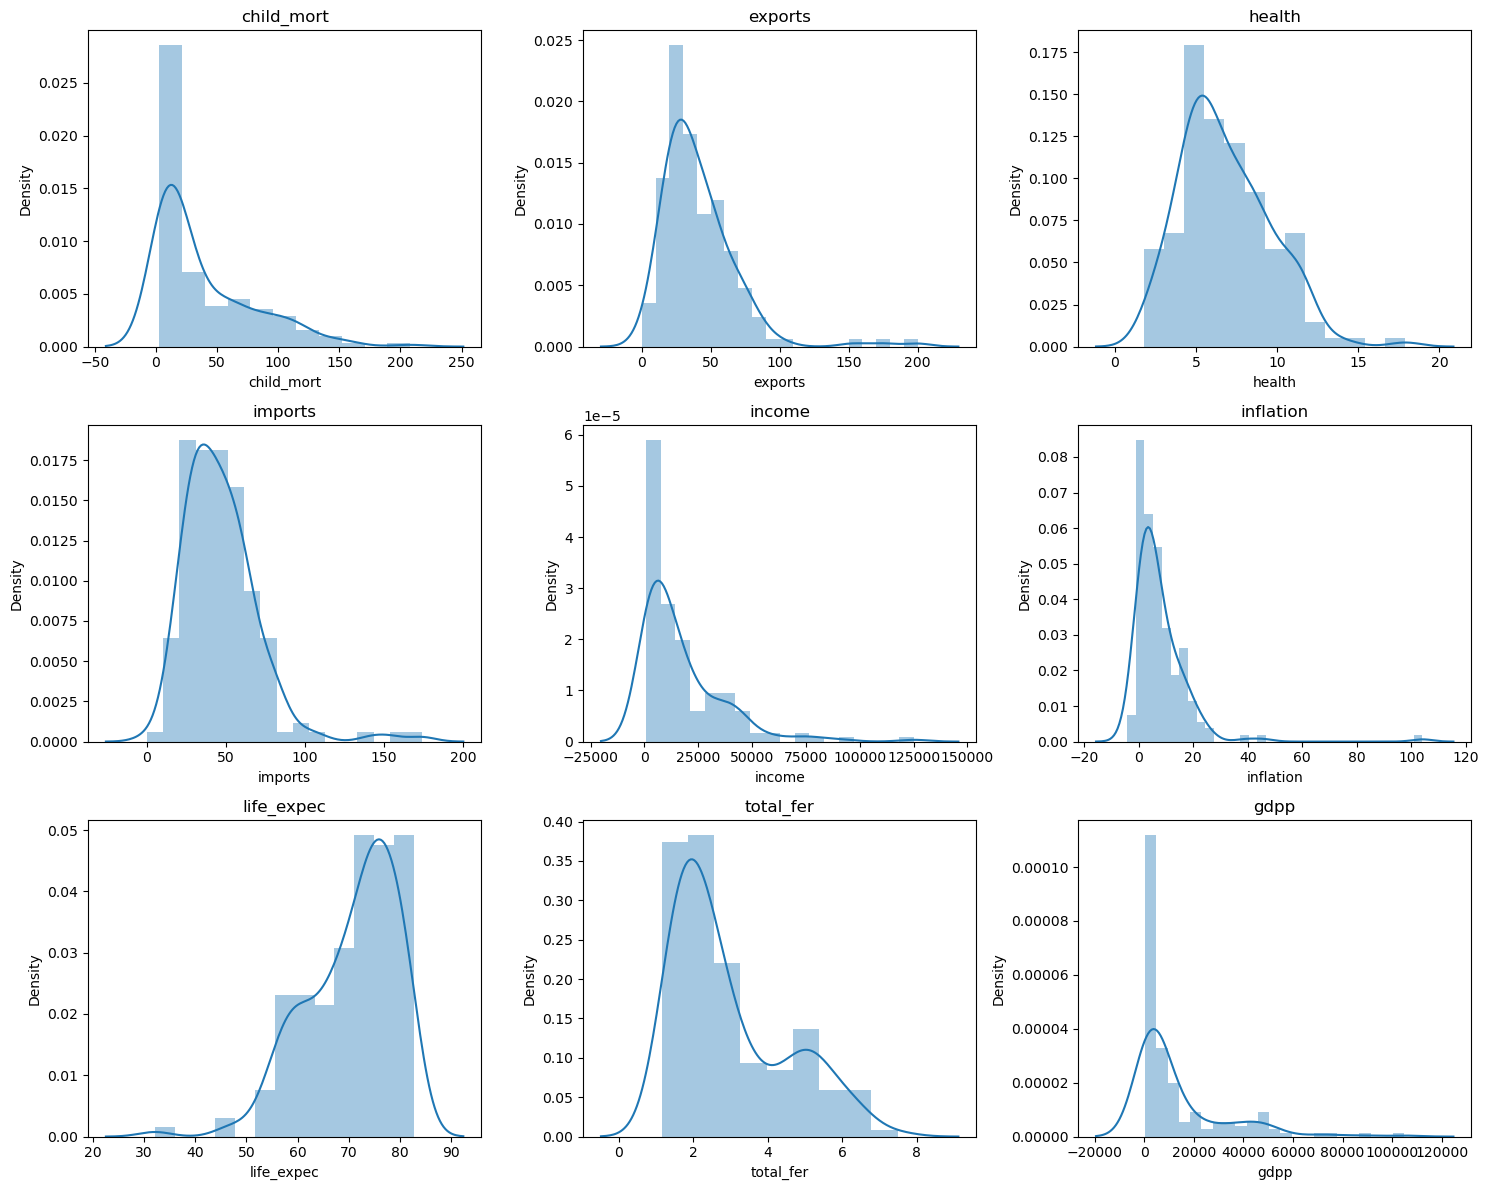

In [ ]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.distplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

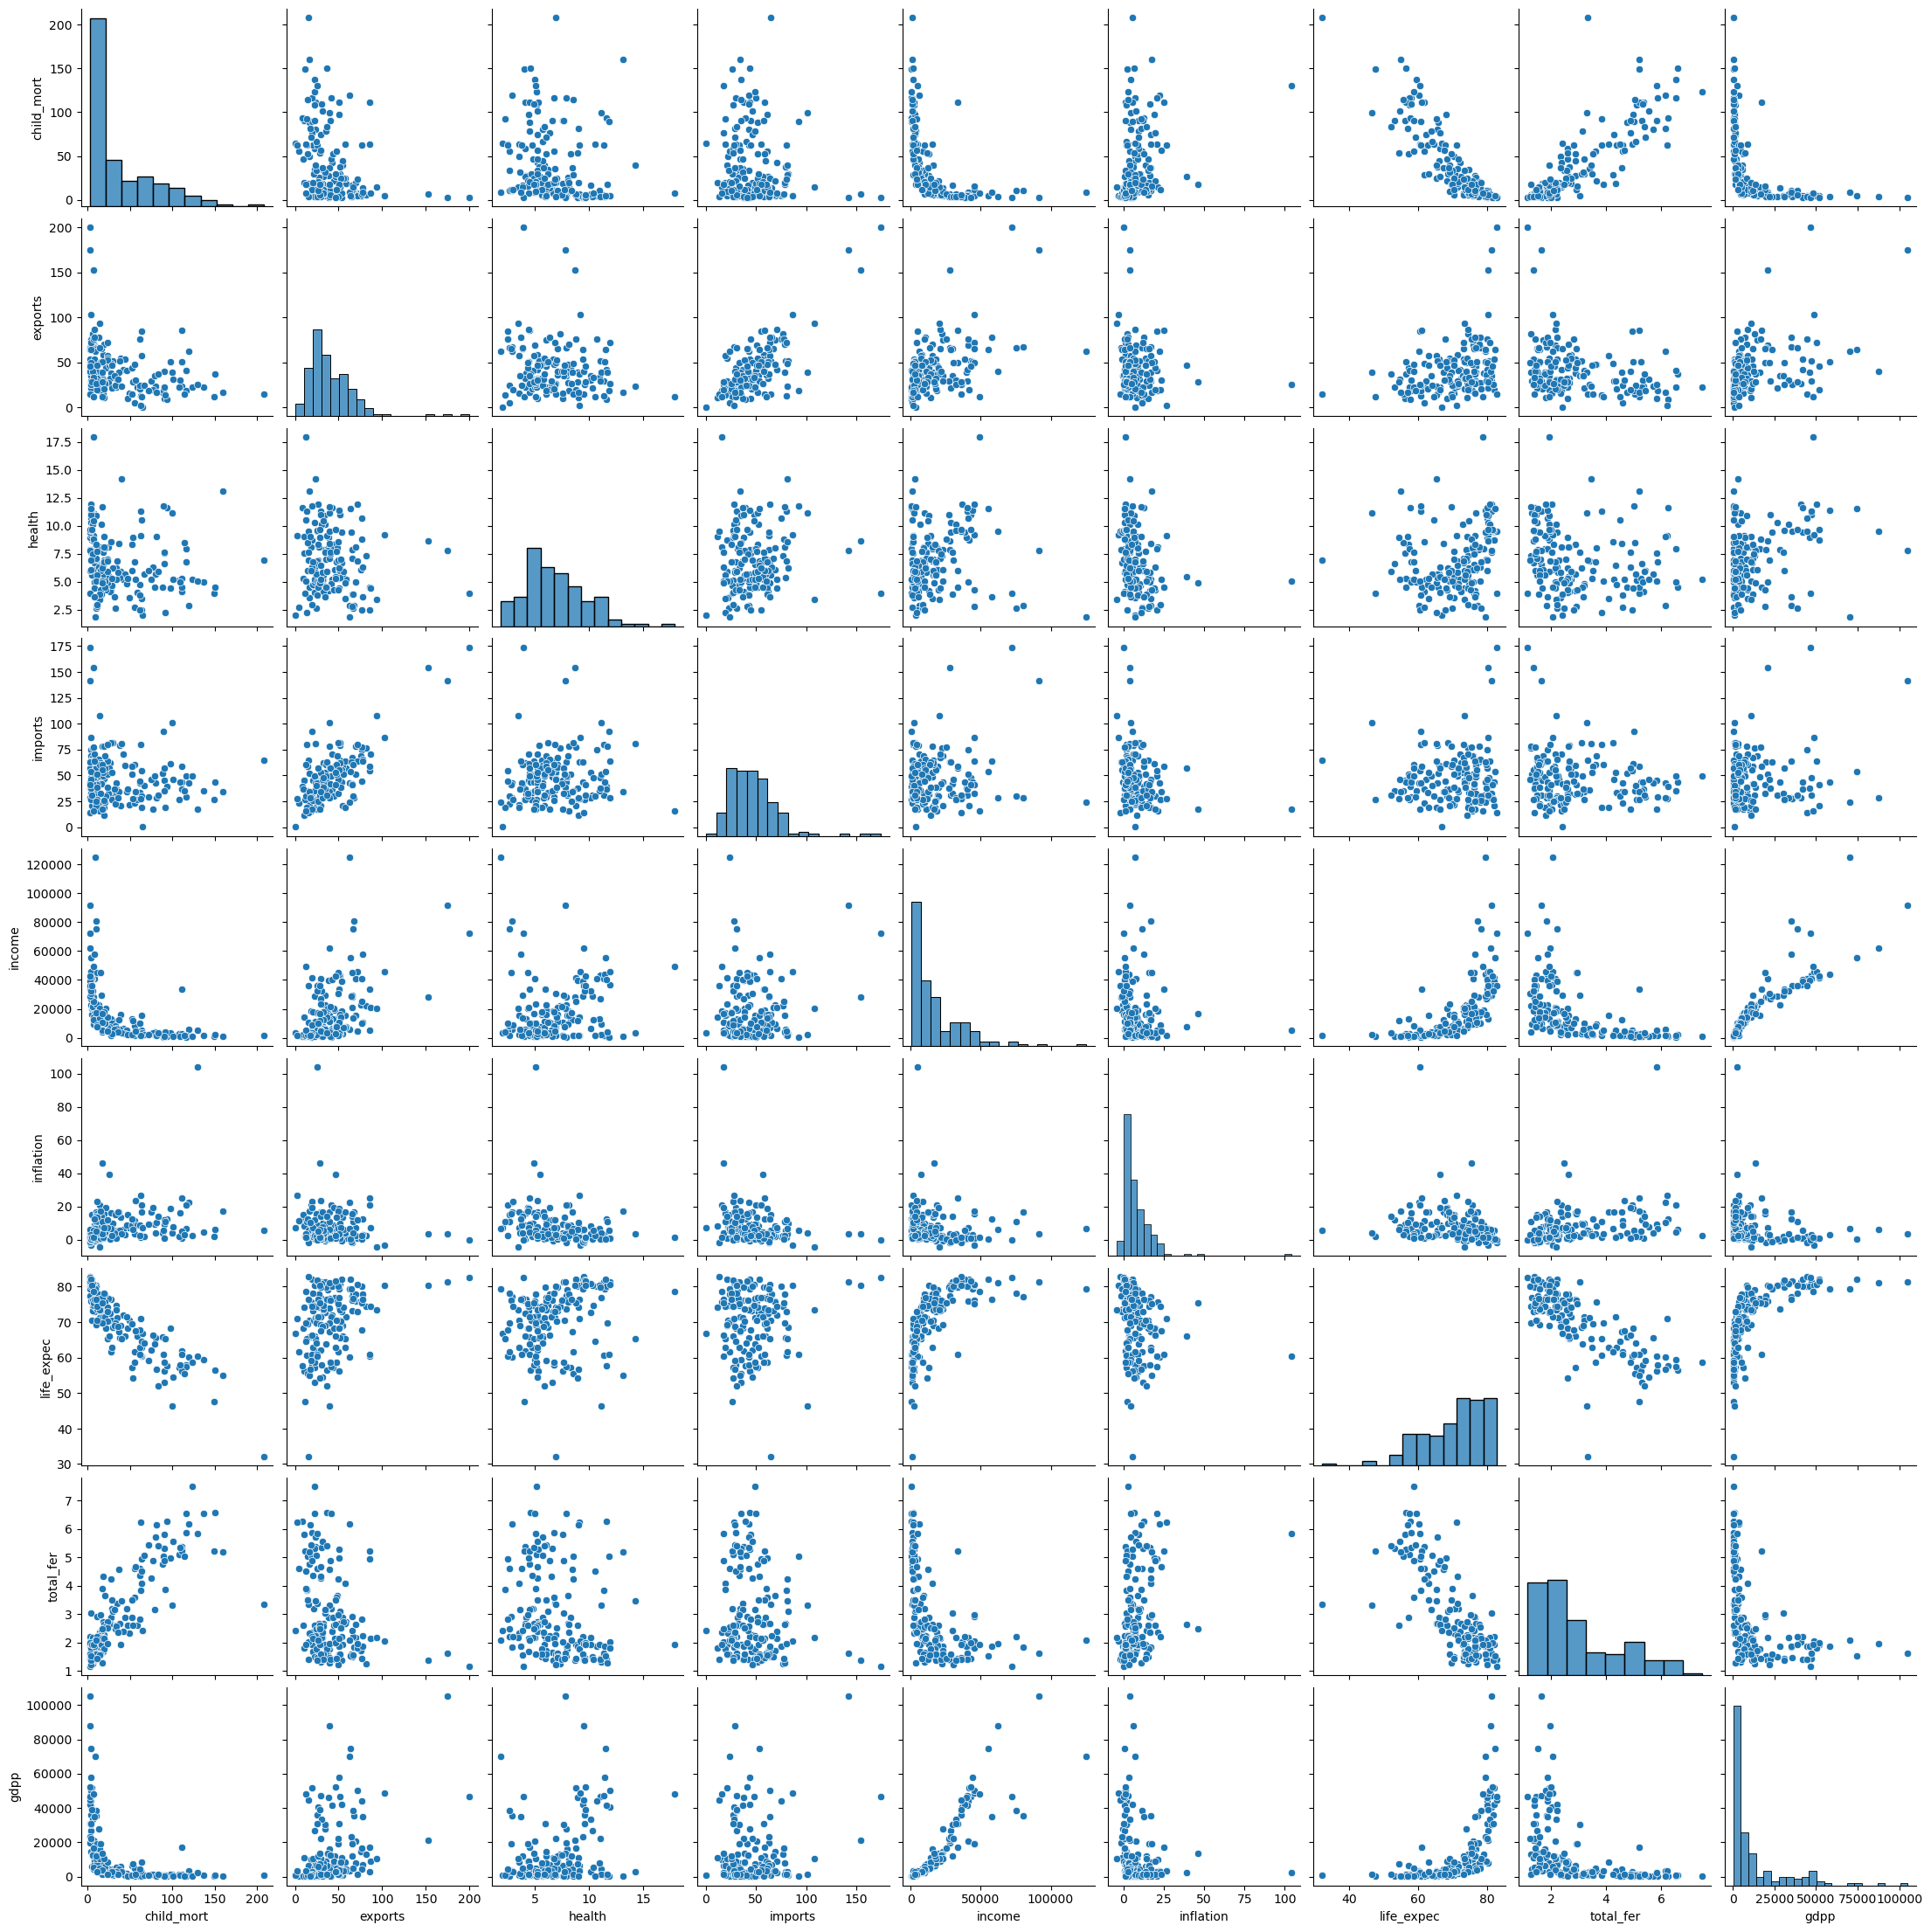

In [ ]:
sns.pairplot(data=df)

In [ ]:
feature_cols = [
    'child_mort',
    'exports',
    'health',
    'imports',
    'income',
    'inflation',
    'life_expec',
    'total_fer',
    'gdpp'
]

---

## KMEANS CLUSTERING

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
# Feature Selection

x = df.drop('country',axis=1)

The country column was excluded because it is an identifier and not a numerical feature used for clustering.

In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [ ]:
wcss = []
for i in range(2,21):
    km = KMeans(n_clusters = i, init='k-means++',random_state=42)
    km.fit(x)
    wcss.append(km.inertia_)

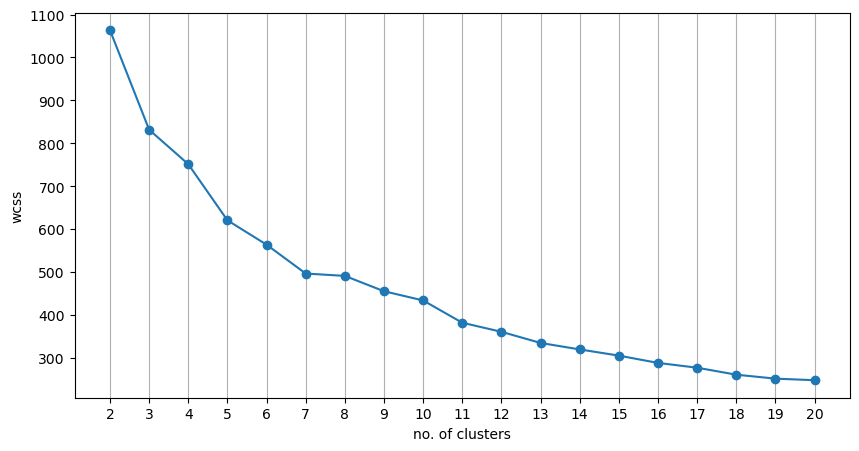

In [ ]:
plt.figure(figsize=(10,5))
plt.plot([i for i in range(2,21)],wcss,marker='o')
plt.xticks([i for i in range(2,21)])
plt.xlabel('no. of clusters')
plt.ylabel('wcss')
plt.grid(axis='x')

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [ ]:
ss = []
no_c = [j for j in range(2,21)]
for i in range(2,21):
    km1 = KMeans(n_clusters=i)
    km1.fit(x)
    ss.append(silhouette_score(x,km1.labels_))

<function matplotlib.pyplot.show(close=None, block=None)>

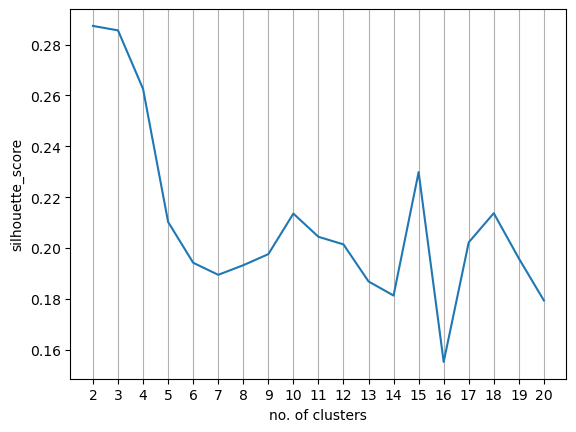

In [ ]:
plt.plot(no_c,ss)
plt.xlabel('no. of clusters')
plt.ylabel('silhouette_score')
plt.xticks(no_c)
plt.grid(axis='x')
plt.show

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)

    score = silhouette_score(x, labels)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.2663
K = 3, Silhouette Score = 0.2856
K = 4, Silhouette Score = 0.2880
K = 5, Silhouette Score = 0.3009
K = 6, Silhouette Score = 0.2357
K = 7, Silhouette Score = 0.2479
K = 8, Silhouette Score = 0.2020
K = 9, Silhouette Score = 0.1923
K = 10, Silhouette Score = 0.1962


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['K_Cluster'] = kmeans.fit_predict(x)

print(df['K_Cluster'].value_counts().sort_index())

K_Cluster
0    87
1    32
2    44
3     1
4     3
Name: count, dtype: int64


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['K_Cluster'] = kmeans.fit_predict(x)

print(df['K_Cluster'].value_counts().sort_index())

K_Cluster
0    86
1    36
2    45
Name: count, dtype: int64


Although the Silhouette Score was slightly higher for K = 5, it resulted in two very small clusters. Therefore, K = 3 was selected because it produced more balanced and interpretable clusters while also matching the Elbow Method.

In [ ]:
kmn = KMeans(n_clusters = 3, random_state=42)
df['K_Cluster'] = kmn.fit_predict(x)

In [ ]:
# WCSS (Inertia)
wcss = kmn.inertia_
print("WCSS (Inertia):", wcss)

# Silhouette Score
silhouette = silhouette_score(x, kmn.labels_)
print("Silhouette Score:", silhouette)

# Calinski-Harabasz Index
calinski = calinski_harabasz_score(x, kmn.labels_)
print("Calinski-Harabasz Index:", calinski)

WCSS (Inertia): 831.5351582151585
Silhouette Score: 0.285600988953231
Calinski-Harabasz Index: 66.21501987305058


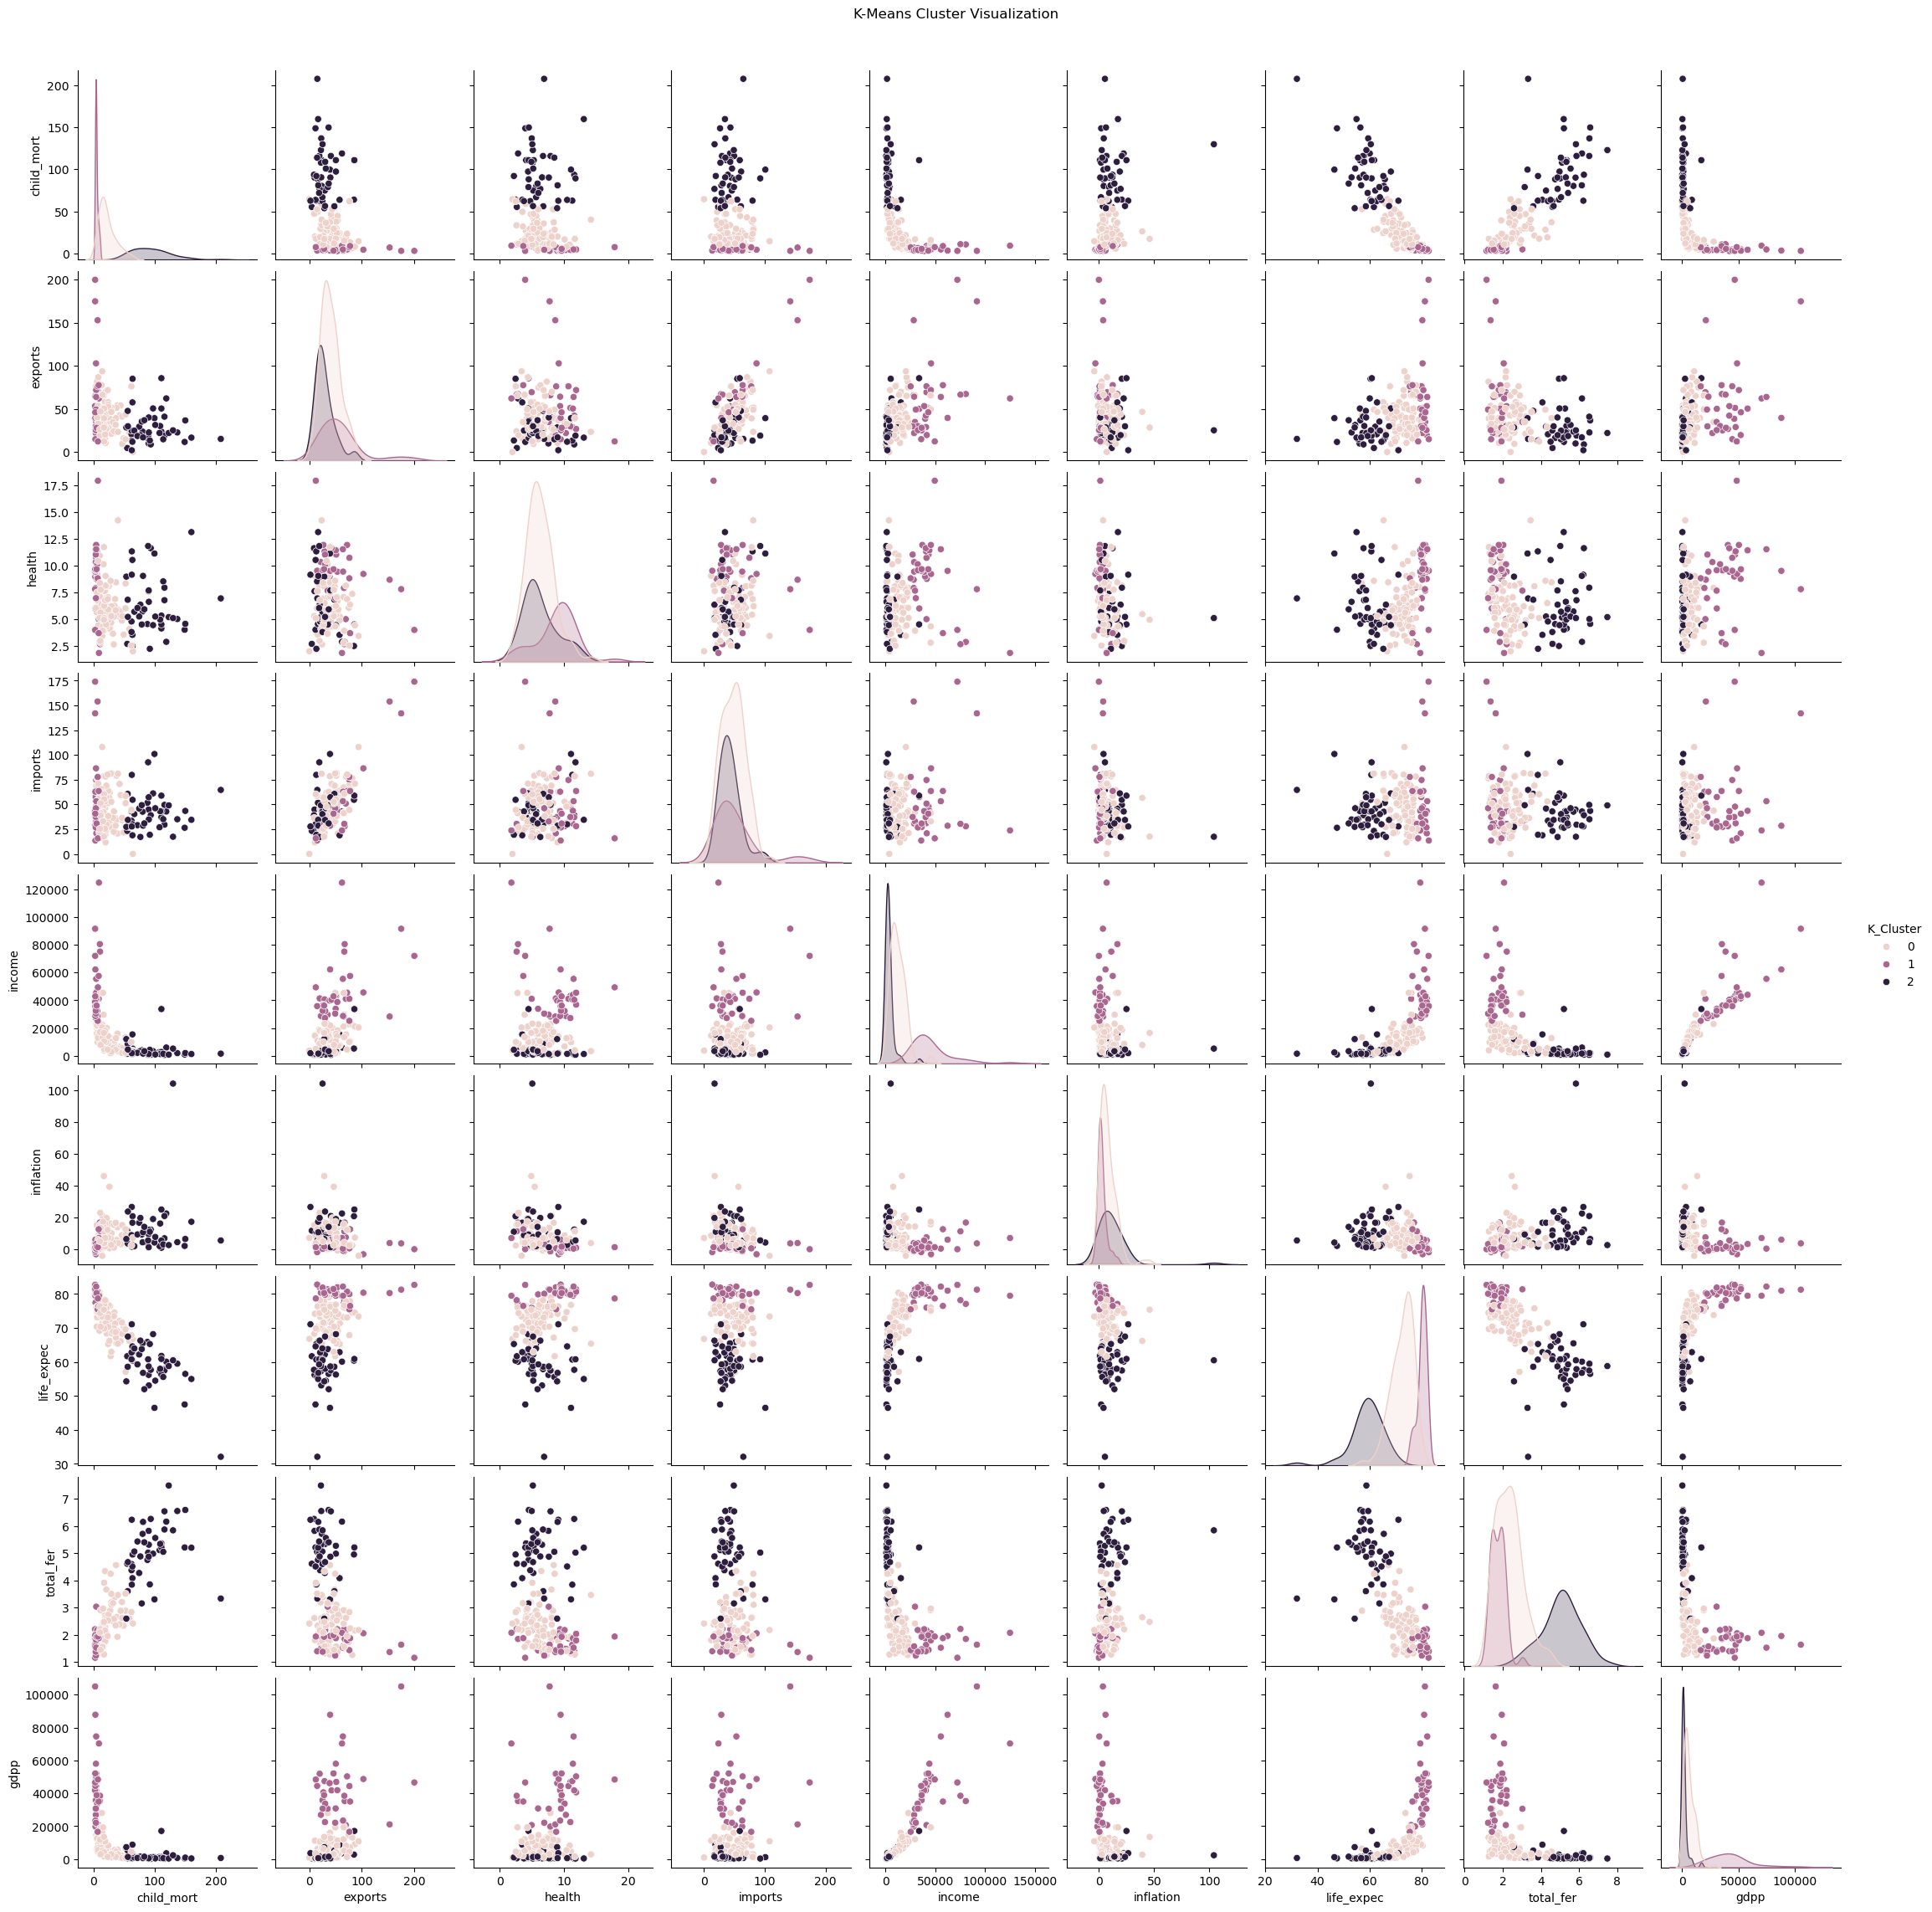

In [ ]:
sns.pairplot(data=df,vars=feature_cols,hue='K_Cluster')
plt.suptitle("K-Means Cluster Visualization", y=1.02)
plt.show()

In [ ]:
kmeans_profile = (df.groupby('K_Cluster')[feature_cols].mean().round(2))

kmeans_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
K_Cluster,,,,,,,,,
0,22.46,40.27,6.25,47.36,12321.74,7.72,72.57,2.34,6461.77
1,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
2,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71


The cluster profiling table shows clear socio-economic differences among the three clusters.  
- Cluster 1 consists of countries with the highest income, GDP per capita, and life expectancy, along with the lowest child mortality, representing Developed Countries.
- Cluster 0 contains countries with moderate economic and health indicators, representing Developing Countries.
- Cluster 2 includes countries with the lowest income and GDP per capita, the highest child mortality and fertility rates, and the lowest life expectancy, representing Least Developed Countries.

In [ ]:
cluster_names = {
    0: 'Developing Countries',
    1: 'Developed Countries',
    2: 'Least Developed Countries'
}

df['K_Cluster_Name'] = df['K_Cluster'].map(cluster_names)

In [ ]:
df.groupby('K_Cluster_Name').size()

K_Cluster_Name
Developed Countries          36
Developing Countries         86
Least Developed Countries    45
dtype: int64

In [ ]:
for cluster in sorted(df['K_Cluster'].unique()):
    print(f"\n{cluster_names[cluster]}")

    print(df[df['K_Cluster'] == cluster]['country'].head(10).tolist())


Developing Countries
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus']

Developed Countries
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland']

Least Developed Countries
['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.']


---

## HIERARCHICAL CLUSTERING

In [ ]:
import scipy.cluster.hierarchy as sc

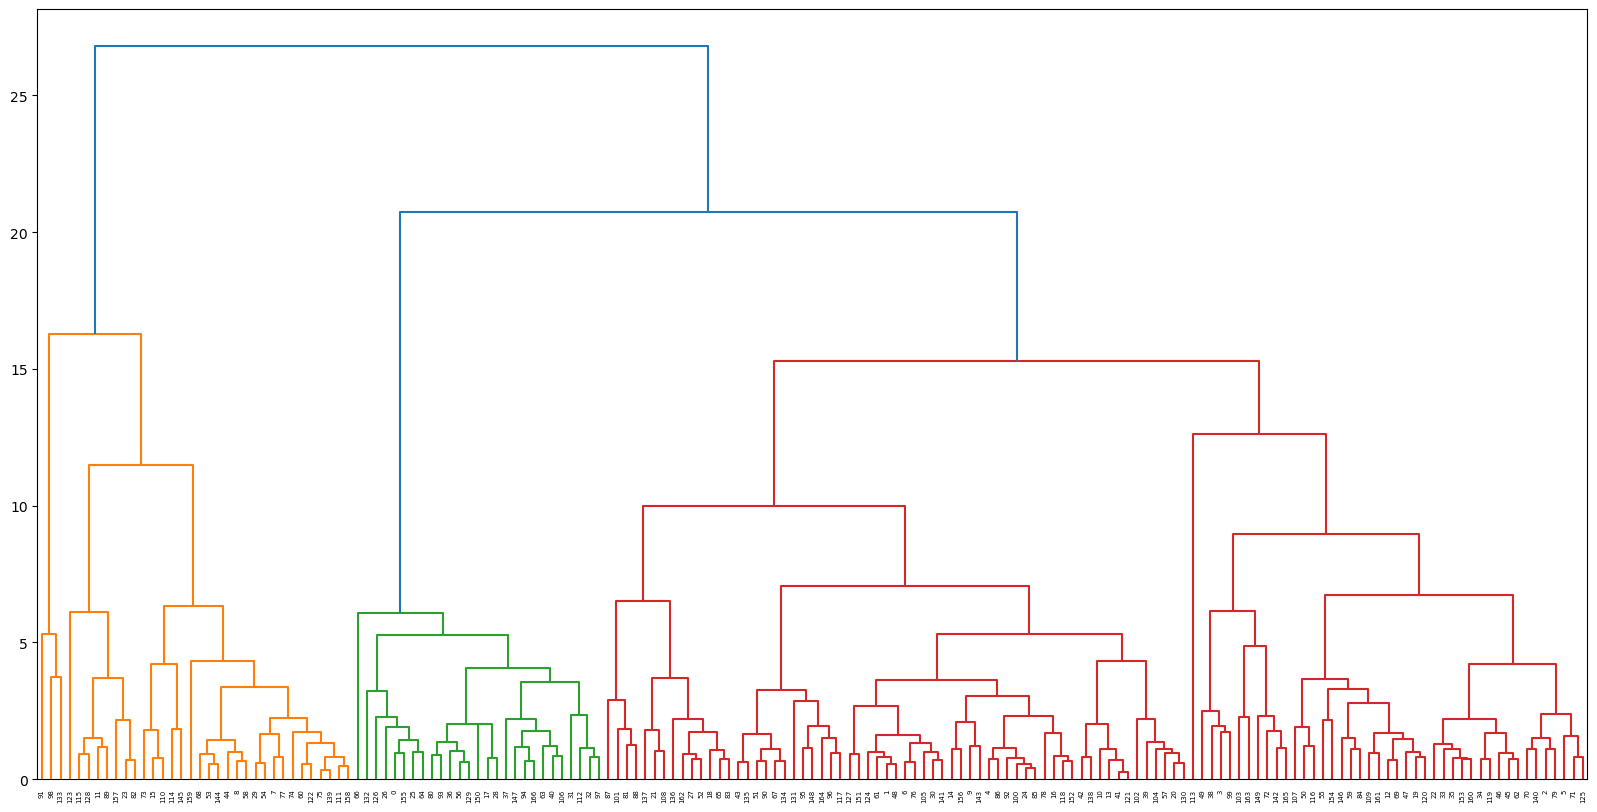

In [ ]:
plt.figure(figsize=(20,10))
sc.dendrogram(sc.linkage(x,method='ward',metric='euclidean')) 
plt.show()

A dendrogram was plotted using Ward linkage to visualize the hierarchical merging process and estimate an appropriate number of clusters.

In [ ]:
from sklearn.cluster import AgglomerativeClustering 

In [ ]:
# Linkage Method Comparison
# Different linkage methods (Single, Complete, Average, and Ward) were compared using cluster size distribution and Silhouette Score. Based on the results, Ward linkage was selected because it produced balanced and interpretable clusters.

for linkage in ['single', 'complete', 'average', 'ward']:
    print(f"\n{'='*40}")
    print(f"Linkage: {linkage}")

    for k in [2, 3]:
        hc = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )

        labels = hc.fit_predict(x)

        print(f"\nNumber of Clusters: {k}")
        print("Cluster Sizes:")
        print(pd.Series(labels).value_counts().sort_index())

        print(f"Silhouette Score: {silhouette_score(x, labels):.3f}")


Linkage: single

Number of Clusters: 2
Cluster Sizes:
0    166
1      1
Name: count, dtype: int64
Silhouette Score: 0.630

Number of Clusters: 3
Cluster Sizes:
0    165
1      1
2      1
Name: count, dtype: int64
Silhouette Score: 0.569

Linkage: complete

Number of Clusters: 2
Cluster Sizes:
0    112
1     55
Name: count, dtype: int64
Silhouette Score: 0.273

Number of Clusters: 3
Cluster Sizes:
0     55
1    109
2      3
Name: count, dtype: int64
Silhouette Score: 0.290

Linkage: average

Number of Clusters: 2
Cluster Sizes:
0    166
1      1
Name: count, dtype: int64
Silhouette Score: 0.630

Number of Clusters: 3
Cluster Sizes:
0    163
1      1
2      3
Name: count, dtype: int64
Silhouette Score: 0.562

Linkage: ward

Number of Clusters: 2
Cluster Sizes:
0    133
1     34
Name: count, dtype: int64
Silhouette Score: 0.315

Number of Clusters: 3
Cluster Sizes:
0     34
1    106
2     27
Name: count, dtype: int64
Silhouette Score: 0.246


In [ ]:
ac = AgglomerativeClustering(n_clusters=2,linkage='ward')
df['H_cluster'] = ac.fit_predict(x)

In [ ]:
# Silhouette Score
silhouette = silhouette_score(x, df['H_cluster'])
print("Silhouette Score:", silhouette)

# Calinski-Harabasz Index
calinski = calinski_harabasz_score(x, df['H_cluster'])
print("Calinski-Harabasz Index:", calinski)

Silhouette Score: 0.3153134331018189
Calinski-Harabasz Index: 51.883430293657675


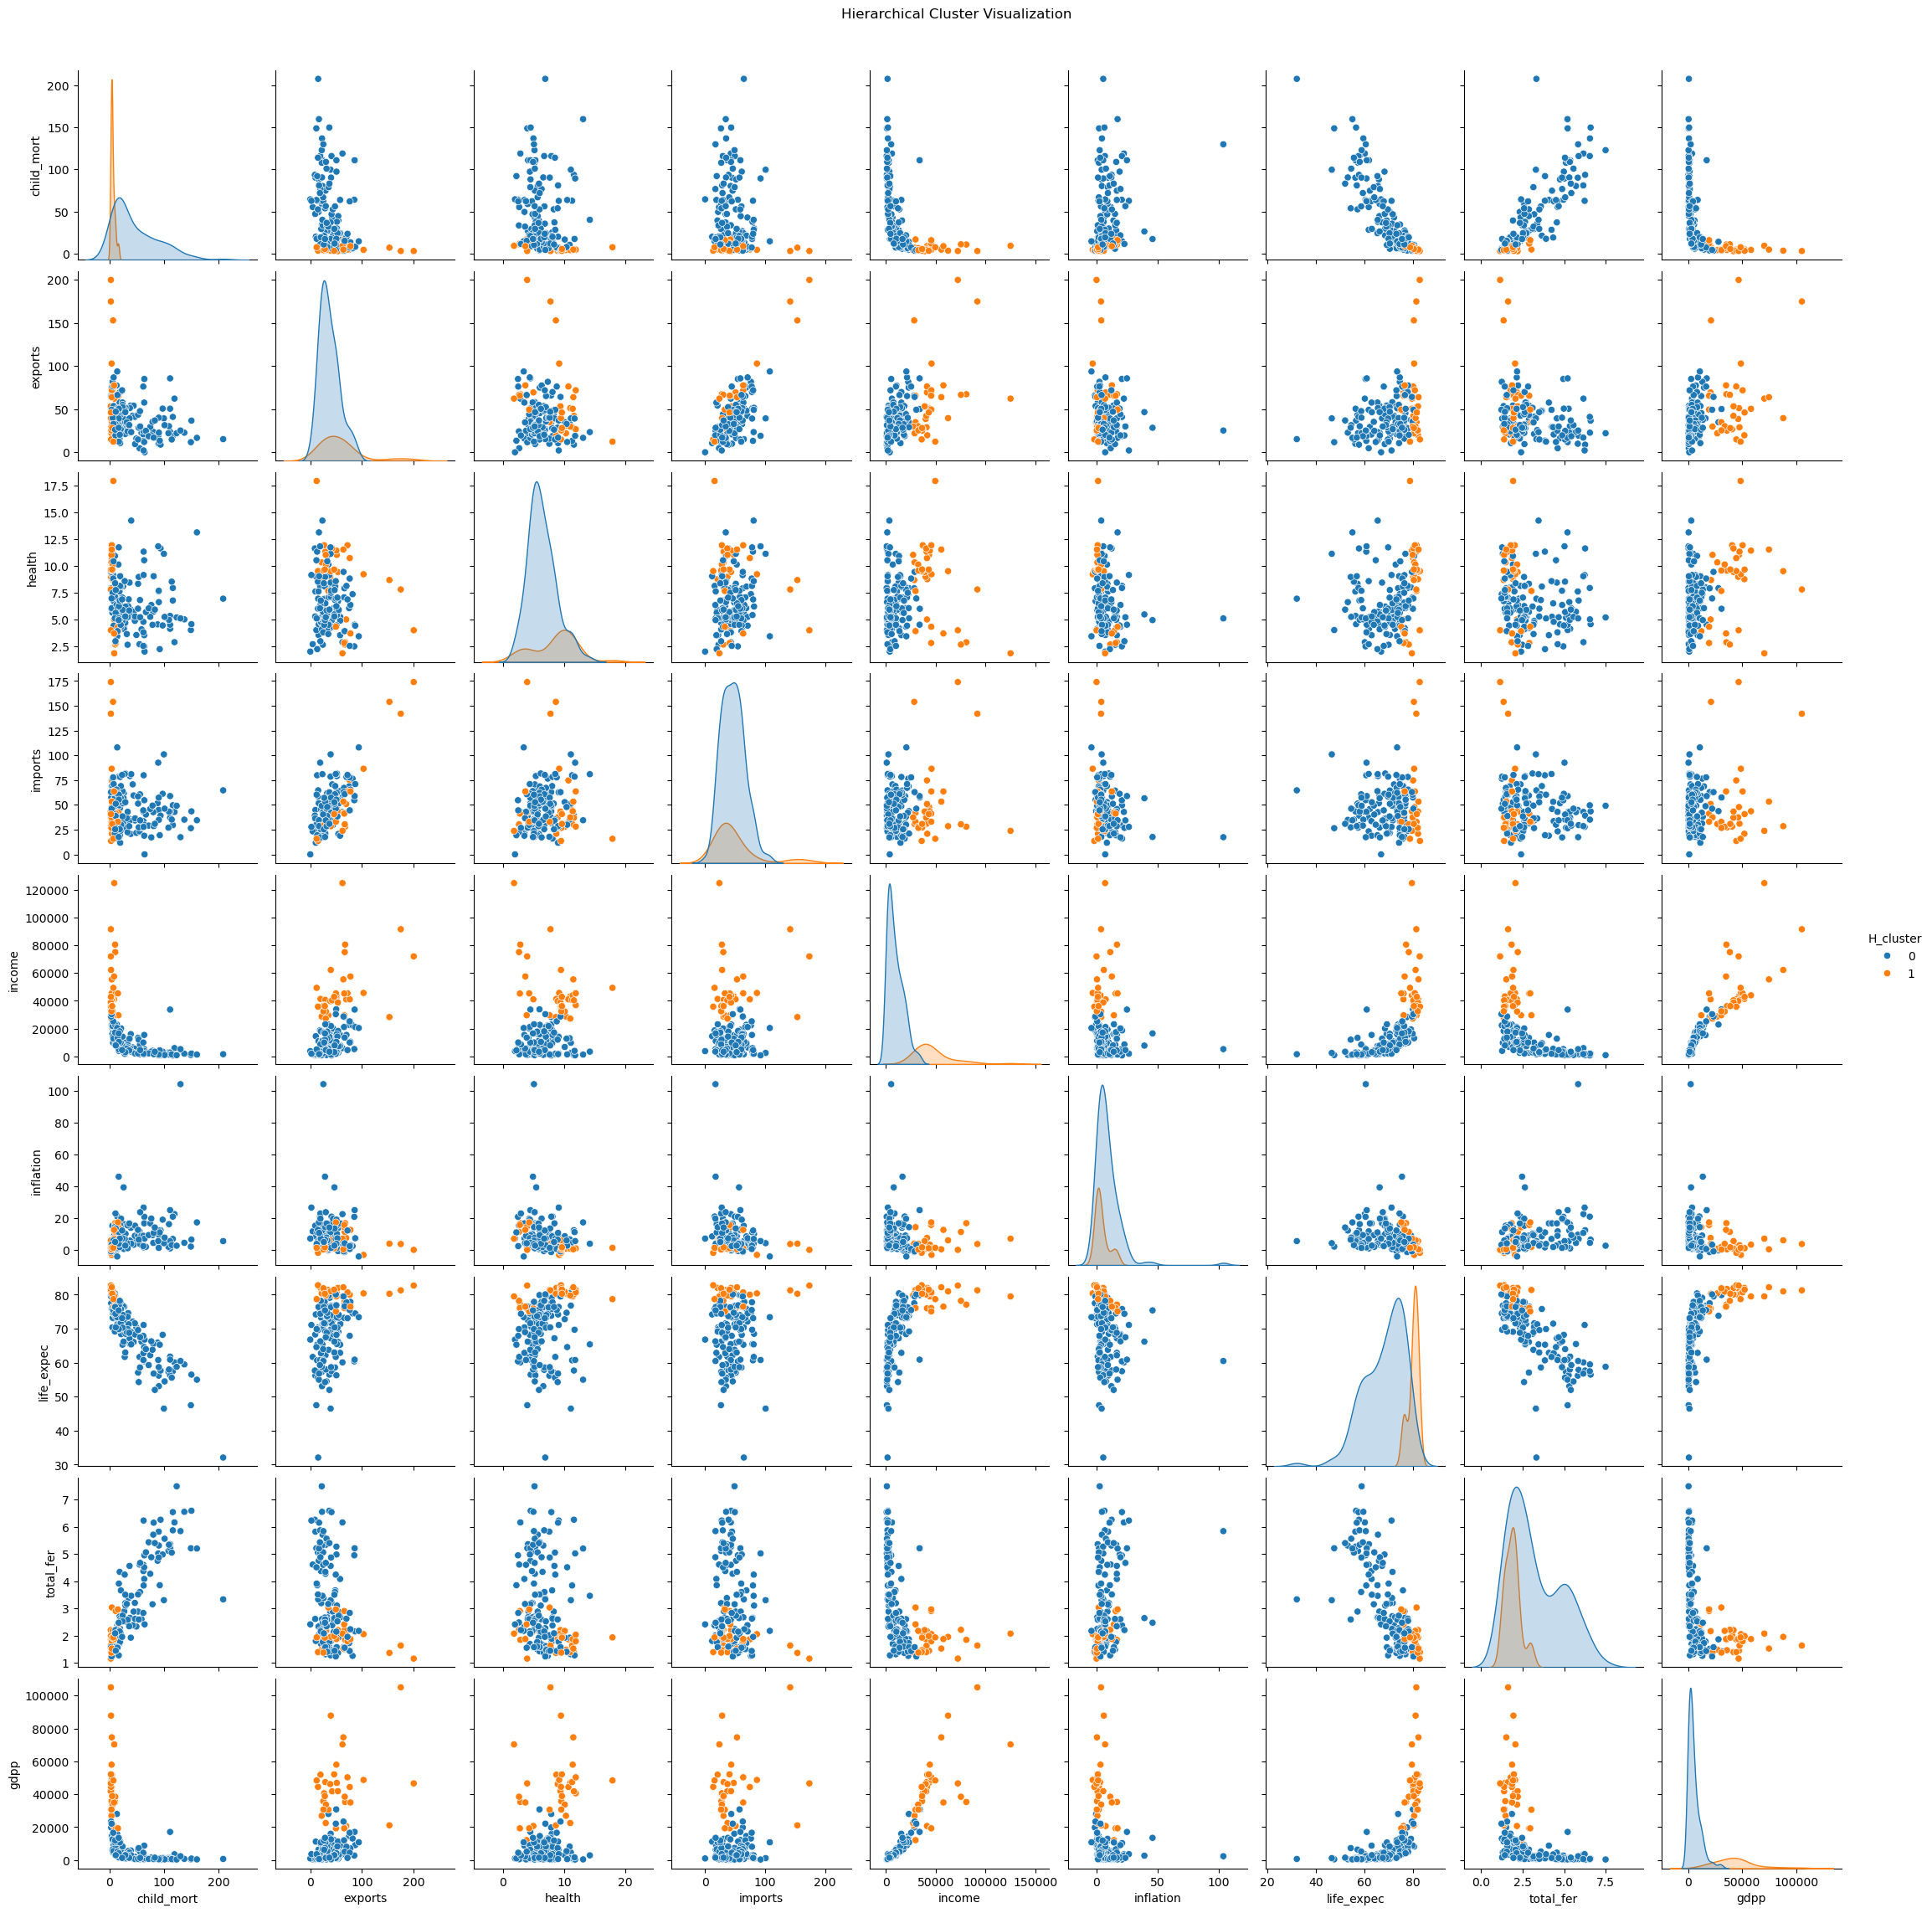

In [ ]:
sns.pairplot(data=df,vars=feature_cols,hue='H_cluster')
plt.suptitle("Hierarchical Cluster Visualization", y=1.02)
plt.show()

In [ ]:
hc_profile = (df.groupby('H_cluster')[feature_cols].mean().round(2))

hc_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
H_cluster,,,,,,,,,
0,46.53,36.66,6.38,46.38,9362.13,8.72,68.15,3.22,5242.21
1,5.96,58.51,8.50,48.90,47588.24,4.12,79.98,1.89,43170.59


In [ ]:
cluster_names = {
    0: 'Developing Countries',
    1: 'Developed Countries'
}

df['H_Cluster_Name'] = df['H_cluster'].map(cluster_names)

- Cluster 0 contains 133 countries with lower income and GDP per capita, lower life expectancy, and higher child mortality and fertility rates. These characteristics indicate Developing Countries.
- Cluster 1 contains 34 countries with high income, high GDP per capita, high life expectancy, and low child mortality and fertility rates. These countries represent Developed Countries.
- Overall, the hierarchical clustering model effectively separates countries into two broad groups based on their level of socio-economic development.

In [ ]:
df.groupby('H_Cluster_Name').size()

H_Cluster_Name
Developed Countries      34
Developing Countries    133
dtype: int64

In [ ]:
for cluster in sorted(df['H_cluster'].unique()):
    print(f"\n{cluster_names[cluster]}")
    print(df[df['H_cluster'] == cluster]['country'].head(10).tolist())


Developing Countries
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh']

Developed Countries
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Denmark', 'Finland', 'France', 'Germany']


---

## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
for eps in [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.4, 1.5, 1.6]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(x)

    print(f"\neps = {eps}")
    print(pd.Series(labels).value_counts().sort_index())


eps = 0.3
-1    167
Name: count, dtype: int64

eps = 0.5
-1    167
Name: count, dtype: int64

eps = 0.7
-1    162
 0      5
Name: count, dtype: int64

eps = 0.9
-1    119
 0     33
 1     11
 2      4
Name: count, dtype: int64

eps = 1.1
-1    71
 0    64
 1    16
 2    11
 3     5
Name: count, dtype: int64

eps = 1.3
-1    46
 0    25
 1    96
Name: count, dtype: int64

eps = 1.4
-1     40
 0    127
Name: count, dtype: int64

eps = 1.5
-1     30
 0    137
Name: count, dtype: int64

eps = 1.6
-1     28
 0    139
Name: count, dtype: int64


In [ ]:
db = DBSCAN(eps=1.3, min_samples=5)
df['DBSCAN_Cluster'] = db.fit_predict(x)

In [ ]:
mask = df['DBSCAN_Cluster'] != -1

silhouette = silhouette_score(
    x[mask],
    df.loc[mask,'DBSCAN_Cluster']
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.4077511058060232


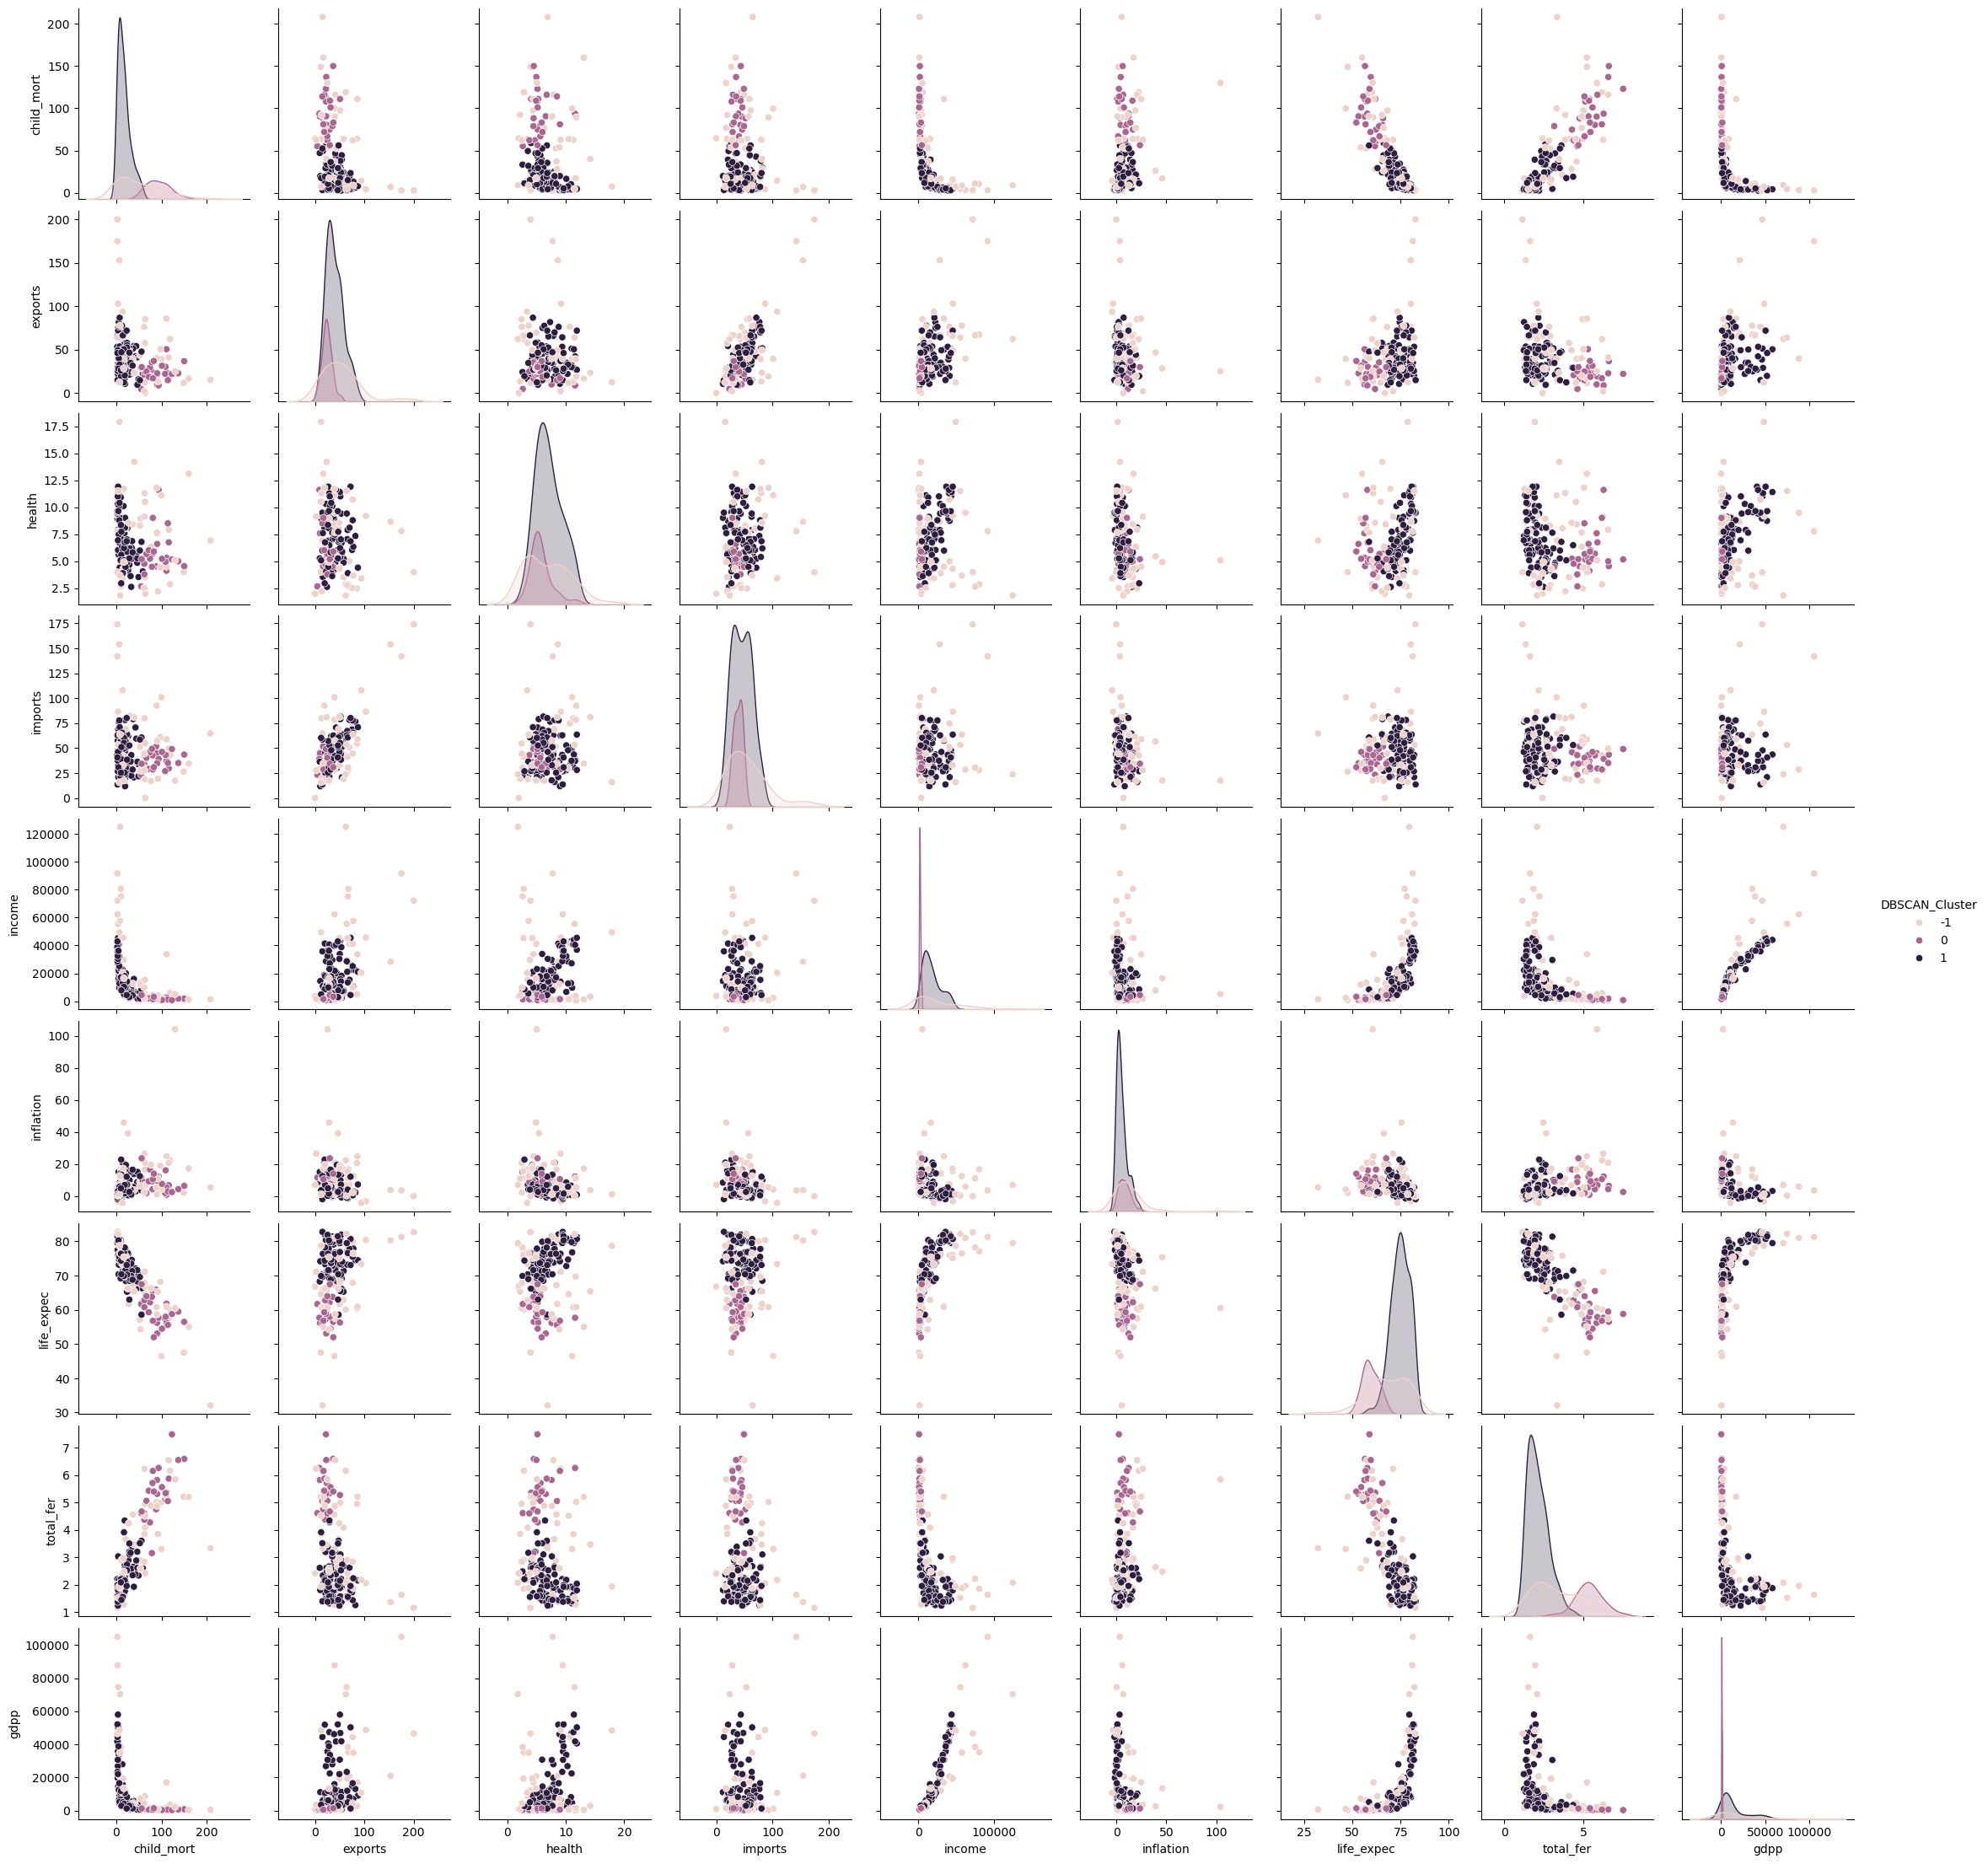

In [ ]:
sns.pairplot(data=df,vars=feature_cols,hue='DBSCAN_Cluster')

plt.show()

In [ ]:
dbscan_profile = (
    df[df['DBSCAN_Cluster'] != -1]
      .groupby('DBSCAN_Cluster')[feature_cols]
      .mean()
      .round(2)
)

dbscan_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
DBSCAN_Cluster,,,,,,,,,
0,92.60,23.98,5.73,38.45,1963.44,8.18,59.42,5.35,775.32
1,17.29,39.47,7.06,45.04,17329.79,5.23,74.75,2.12,13655.35


In [ ]:
cluster_names = {
    -1: 'Noise Points',
     0: 'Least Developed Countries',
     1: 'Developing & Developed Countries'
}

df['DBSCAN_Cluster_Name'] = df['DBSCAN_Cluster'].map(cluster_names)

- Cluster 0 represents countries with very high child mortality, low income, low GDP per capita, high fertility, and lower life expectancy, indicating Least Developed Countries.
- Cluster 1 includes countries with higher income and GDP, better healthcare outcomes, higher life expectancy, and lower fertility rates, representing Developing and Developed Countries.
- DBSCAN also identified several countries as noise (-1), indicating that these countries do not belong to any dense cluster and can be considered outliers based on the selected parameters.

In [ ]:
df.groupby('DBSCAN_Cluster_Name').size()

DBSCAN_Cluster_Name
Developing & Developed Countries    96
Least Developed Countries           25
Noise Points                        46
dtype: int64

In [ ]:
for name in df['DBSCAN_Cluster_Name'].dropna().unique():
    print(f"\n{name}")
    print(df[df['DBSCAN_Cluster_Name'] == name]['country'].head(10).tolist())


Least Developed Countries
['Afghanistan', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Chad', 'Comoros', "Cote d'Ivoire", 'Eritrea', 'Gambia']

Developing & Developed Countries
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bangladesh']

Noise Points
['Angola', 'Bahrain', 'Belgium', 'Botswana', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon']


---

## Comparison of Clustering Algorithms

| Algorithm           | Clusters Found |        Silhouette Score | Key Result                                                              |
| ------------------- | -------------: | ----------------------: | ----------------------------------------------------------------------- |
| K-Means             |              3 |               **0.286** | Produced three meaningful and well-balanced socio-economic clusters.    |
| Hierarchical (Ward) |              2 |               **0.315** | Generated two interpretable clusters with clear separation.             |
| DBSCAN              |   2 + 46 Noise | **0.407** | Identified outlier countries but classified many observations as noise. |

*Note: The DBSCAN Silhouette Score was calculated after excluding noise points (-1), so it is not directly comparable with the scores of K-Means and Hierarchical Clustering, which were computed using all clustered observations.

## Conclusion

- Three clustering algorithms were applied to group countries based on socio-economic and health indicators.
- K-Means created three meaningful and balanced clusters, making it easy to identify different levels of country development.
- Hierarchical Clustering also produced clear and easy-to-understand clusters, and its results were similar to those of K-Means.
- DBSCAN was able to identify outlier countries, but it also classified many countries as noise because the dataset did not have the dense clusters that DBSCAN works best with.
- Although DBSCAN had a higher Silhouette Score, the score was calculated after excluding the noise points, so it cannot be directly compared with the scores of K-Means and Hierarchical Clustering.
- Overall, K-Means was the most suitable algorithm for this dataset because it grouped all countries into three meaningful and well-balanced clusters, making the results easier to interpret and compare.